In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

In [2]:
df = pd.read_csv("../data/energy.csv")
X = df.drop("PE", axis=1)
y = df["PE"]
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9564 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
dtypes: float64(4)
memory usage: 299.1 KB


# Train test split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Data cleaning

In [60]:
num_pipeline = make_pipeline(
    SimpleImputer(strategy="mean"),
    StandardScaler()
)

attributes = list(X_train.columns)
preprocessing = ColumnTransformer([
    ("num", num_pipeline, attributes)
])

# Model selection

# Model fit and evaluation

mse: 19.809314246705796
r2: 0.9307715504332295


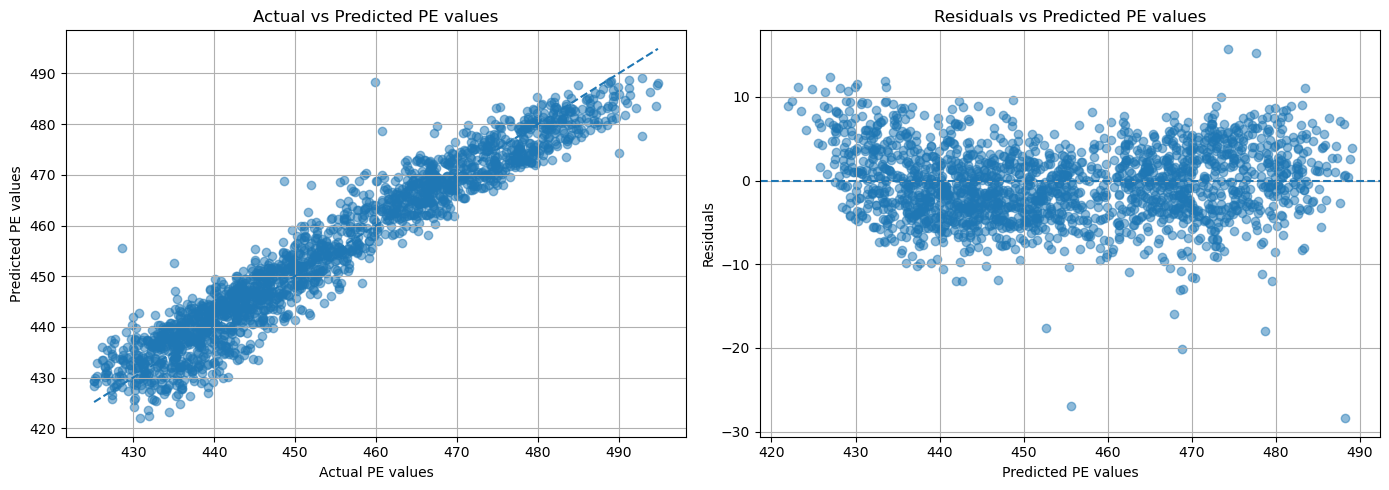

In [61]:
lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"mse: {mse}")
print(f"r2: {r2}")

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: actual vs predicted
axes[0].scatter(y_test, y_pred, alpha=0.5)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
axes[0].set_xlabel("Actual PE values")
axes[0].set_ylabel("Predicted PE values")
axes[0].set_title("Actual vs Predicted PE values")
axes[0].grid(True)

# Panel 2: residuals
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted PE values")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residuals vs Predicted PE values")
axes[1].grid(True)

plt.tight_layout()
plt.show()